cuda


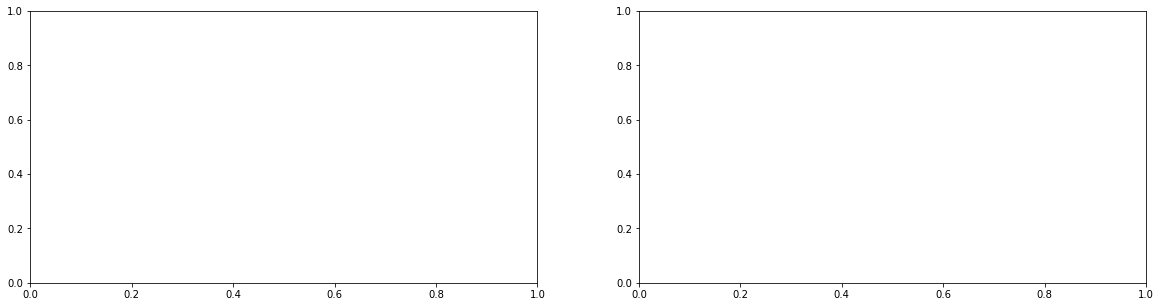

In [1]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list


fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

768 8 3e-4 4.0 tensor(nan) tensor(nan)
768 8 1e-3 4.0 tensor(2.5737) tensor(0.0256)
768 8 3e-3 4.0 tensor(nan) tensor(nan)
768 8 3e-4 4.0 tensor(2.6132) tensor(0.0113)
768 8 1e-3 4.0 tensor(2.5860) tensor(0.0152)
768 8 3e-3 4.0 tensor(2.8320) tensor(0.0558)
768 8 3e-4 4.0 tensor(2.8723) tensor(0.0274)
768 8 1e-3 4.0 tensor(2.8238) tensor(0.0113)
768 8 3e-3 4.0 tensor(nan) tensor(nan)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

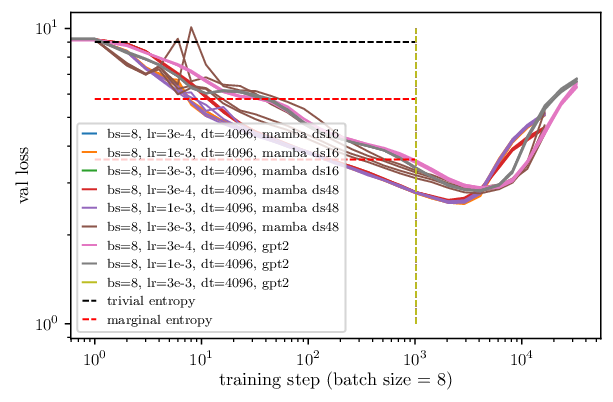

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 1048576
path = f'tinystories/trained/T{T}_mamba/P{P}/'

depth = 12
de = 768
ds = 16

bs = 8
for lr in ['3e-4', '1e-3', '3e-3']:
    for dt in [4096]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, mamba ds{ds}')

depth = 12
de = 768
ds = 48

bs = 8
for lr in ['3e-4', '1e-3', '3e-3']:
    for dt in [4096]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, mamba ds{ds}')


T = 128
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 8
for lr in ['3e-4', '1e-3', '3e-3']:
    for dt in [4096]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, gpt2')



ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 8 3e-4 2.0 tensor(2.0217) tensor(0.0092)
768 8 3e-4 4.0 tensor(2.0534) tensor(0.0094)
768 8 1e-3 2.0 tensor(1.9974) tensor(0.0108)
768 8 1e-3 4.0 tensor(2.0568) tensor(0.0098)
768 16 3e-4 2.0 tensor(2.1017) tensor(0.0093)
768 16 3e-4 4.0 tensor(2.1009) tensor(0.0132)
768 16 1e-3 2.0 tensor(2.0007) tensor(0.0172)
768 16 1e-3 4.0 tensor(2.0689) tensor(0.0129)
768 8 3e-4 4.0 tensor(2.2166) tensor(0.0159)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

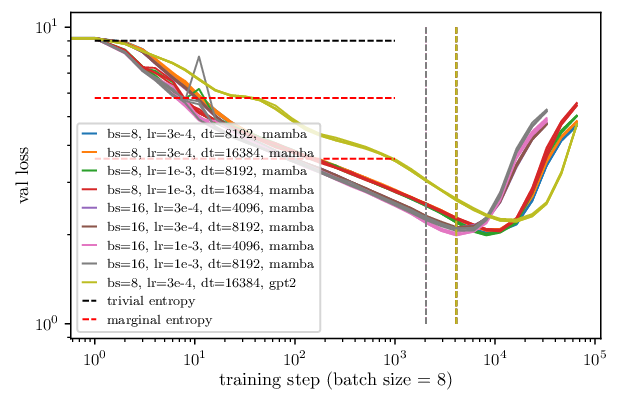

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 4194304
path = f'tinystories/trained/T{T}_mamba/P{P}/'

depth = 12
de = 768
ds = 16

bs = 8
for lr in ['3e-4', '1e-3']:
    for dt in [8192, 16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, mamba')

bs = 16
for lr in ['3e-4', '1e-3']:
    for dt in [ 4096, 8192]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, mamba')


T = 128
P = 4194304
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 8
for lr in ['3e-4']:
    for dt in [16384]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, gpt2')



ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

768 16 3e-4 2.0 tensor(1.4506) tensor(0.0080)
768 16 3e-4 4.0 tensor(1.4453) tensor(0.0161)
768 16 1e-3 2.0 tensor(1.5531) tensor(0.0602)
768 16 1e-3 4.0 tensor(1.4698) tensor(0.0315)
768 32 3e-4 2.0 tensor(1.4565) tensor(0.0050)
768 32 3e-4 4.0 tensor(1.4543) tensor(0.0105)
768 32 1e-3 2.0 tensor(1.4399) tensor(0.0075)
768 32 1e-3 4.0 tensor(1.4385) tensor(0.0059)
768 8 3e-4 4.0 tensor(1.5075) tensor(0.0066)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

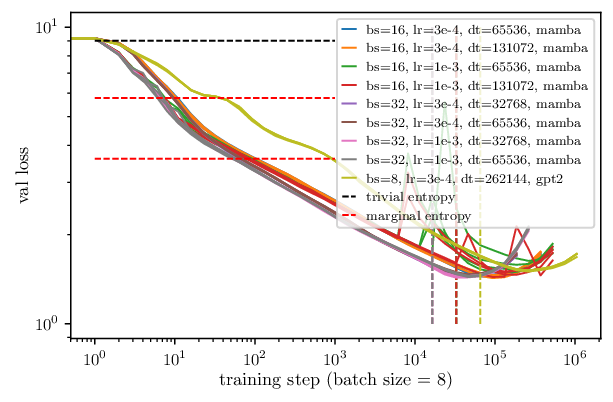

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 67108864
path = f'tinystories/trained/T{T}_mamba/P{P}/'

depth = 12
de = 768
ds = 16

bs = 16
for lr in ['3e-4', '1e-3']:
    for dt in [65536, 131072]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, mamba')

bs = 32
for lr in ['3e-4', '1e-3']:
    for dt in [ 32768, 65536]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, mamba')


T = 128
P = 67108864
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 768
nh = 12

bs = 8
for lr in ['3e-4']:
    for dt in [262144]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, gpt2')



ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

1.3536039674654603 93184 7463266
1.670285708270967 93184 4832330
1.3540313020348549 93184 3909666
1.5436320547014475 93184 10166479
768 32 1e-3 4.0 tensor(1.4134) tensor(0.0801)
1.2800946366041899 2097152 4063180
1.3104981146752834 2097152 14439230
1.2320103012025356 2097152 11197240
1.3064933773130178 2097152 9644289
768 32 1e-3 4.0 tensor(1.2726) tensor(0.0385)
1.225369157269597 1048576 13573738
1.2385699674487114 1048576 10342585
1.2208360750228167 1048576 8210635
1.2285010293126106 1048576 4802360
768 64 1e-3 2.0 tensor(1.2164) tensor(0.0064)
1.2240035682916641 1048576 10892112
1.2131244093179703 1048576 3140579
1.2191078197211027 1048576 4649172
1.2171026431024075 1048576 7460010
768 64 1e-3 4.0 tensor(1.2029) tensor(0.0045)
1024 16 3e-4 4.0 tensor(1.2418) tensor(0.0067)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=16$)')

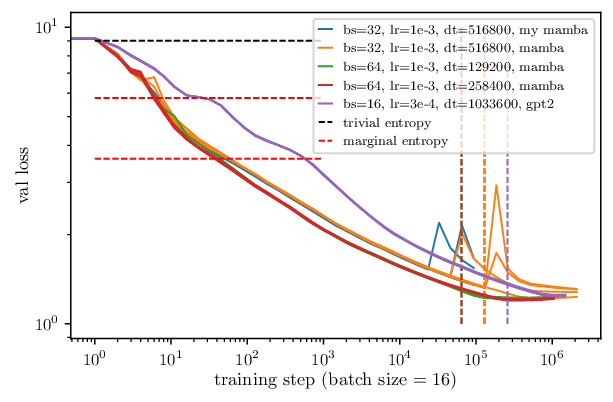

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 128
P = 529203200
path = f'tinystories/trained/T{T}_mamba/P{P}/'

depth = 12
de = 768
ds = 16

bs = 32
for lr in ['1e-3']:
    for dt in [516800]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mymamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
            print(dynamics[-1]['val_loss'], dynamics[-1]['t'], results['config'].seed_model)
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, my mamba')

bs = 32
for lr in ['1e-3']:
    for dt in [516800]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
            print(dynamics[-1]['val_loss'], dynamics[-1]['t'], results['config'].seed_model)
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, mamba')

bs = 64
for lr in ['1e-3']:
    for dt in [129200, 258400]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_mamba_d{depth}_demb{de}_ds{ds}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
            print(dynamics[-1]['val_loss'], dynamics[-1]['t'], results['config'].seed_model)
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, mamba')

T = 128
P = 529203200
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
de = 1024
nh = 16

bs = 16
for lr in ['3e-4']:
    for dt in [1033600]:
        dt_ep = dt//(P/(bs*T))
        i += 1
        prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
        collection = collect( path, prefix)
        mean_loss = []
        for entry in collection:

            results = torch.load(path+prefix+entry['ending'])
            dynamics = results['dynamics']
            ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
            mean_loss.append(results['best']['loss'])
        #     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
        print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
        ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
        custom_lines.append(Line2D([0], [0], color=f'C{i}'))
        custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}, gpt2')



ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)